In [1]:
import numpy as np
import random
from pprint import pprint
from itertools import combinations
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime


from visualize_cards import Card
from helpers import board_check, display_grid, print_cards_in_row, combo_counter, count_monoattr, hash_colinearity

## How many sets of 12 don't have any sets?

for any given 3 cards amongst any given 12 cards, 

In [11]:
choices = [0, 1, 2]
random_board = {j: [random.choice(choices) for _ in range(4)] for j in range(15)}
display_grid(random_board)
print('--------')

counts, sets = board_check(random_board)
print(f'\n{counts} Sets Found:')

for comb in combinations(range(len(random_board)), 3):
    cards = [random_board[c] for c in comb]
    is_set = hash_colinearity(*cards)
    if is_set:
        monoattr = count_monoattr(*cards)
        cards = list(map(lambda x: Card(random_board[x]), comb))
        print_cards_in_row(cards)
        print(f'monoattributes: {monoattr}')


  0     1     2     3
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│(■)│ │   │ │   │ │(☐)│ 
│(■)│ │(▥)│ │(▥)│ │   │ 
│(■)│ │   │ │   │ │(☐)│ 
└───┘ └───┘ └───┘ └───┘ 
  4     5     6     7
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│╔■╝│ │<☐>│ │   │ │(■)│ 
│   │ │   │ │<■>│ │(■)│ 
│╔■╝│ │<☐>│ │   │ │(■)│ 
└───┘ └───┘ └───┘ └───┘ 
  8     9    10    11
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│<■>│ │<☐>│ │╔▥╝│ │   │ 
│<■>│ │   │ │╔▥╝│ │<■>│ 
│<■>│ │<☐>│ │╔▥╝│ │   │ 
└───┘ └───┘ └───┘ └───┘ 
 12    13    14
┌───┐ ┌───┐ ┌───┐ 
│╔▥╝│ │   │ │<▥>│ 
│╔▥╝│ │╔▥╝│ │<▥>│ 
│╔▥╝│ │   │ │<▥>│ 
└───┘ └───┘ └───┘ 
--------

7 Sets Found:
┌───┐ ┌───┐ ┌───┐ 
│(■)│ │<☐>│ │   │ 
│(■)│ │   │ │╔▥╝│ 
│(■)│ │<☐>│ │   │ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│   │ │(☐)│ │(■)│ 
│(▥)│ │   │ │(■)│ 
│   │ │(☐)│ │(■)│ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│   │ │(☐)│ │(■)│ 
│(▥)│ │   │ │(■)│ 
│   │ │(☐)│ │(■)│ 
└───┘ └───┘ └───┘ 
monoattributes: 1
┌───┐ ┌───┐ ┌───┐ 
│(☐)│ │<■>│ │   │ 
│   │ │<■>│ │╔▥╝│ 
│(☐)│ │<■>│ │   │ 
└───┘ └──

I wonder how low it will take to iterate through every set of 12... 

In [6]:
every_possible_card = [] #81 cards, not too much RAM
for a in range(3):
    for b in range(3):
        for c in range(3):
            for d in range(3):
                every_possible_card.append((a, b, c, d))

In [7]:
total_boards = combo_counter(81, 12)
print(f'Total Boards: {total_boards}')

start_time = datetime.now()
set_counter = defaultdict(int)
trials = int(1e5)
for _ in tqdm(range(trials)):
    combo = random.sample(every_possible_card, 12)
    n_sets, sets = board_check(combo)
    set_counter[n_sets] += 1
taken_time = datetime.now() - start_time

outcomes = {k: 100*(v/trials) for k, v in set_counter.items()}
pprint(outcomes)


sampled_pct = trials / total_boards

print('PURE PYTHON IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (365.2425 * 24 * 60 * 60)} years.')

Total Boards: 70724320184700


100%|██████████| 100000/100000 [00:15<00:00, 6284.56it/s]

{0: 3.2489999999999997,
 1: 14.66,
 2: 26.057999999999996,
 3: 27.217999999999996,
 4: 18.07,
 5: 7.939,
 6: 2.251,
 7: 0.47200000000000003,
 8: 0.06899999999999999,
 9: 0.01,
 10: 0.004}
PURE PYTHON IMPLEMENTATION:
Tested 1.4139407736807527e-07% of the total space, taking 15.916707 seconds.
At this rate, sampling the full space would take 356.7195850074671 years.


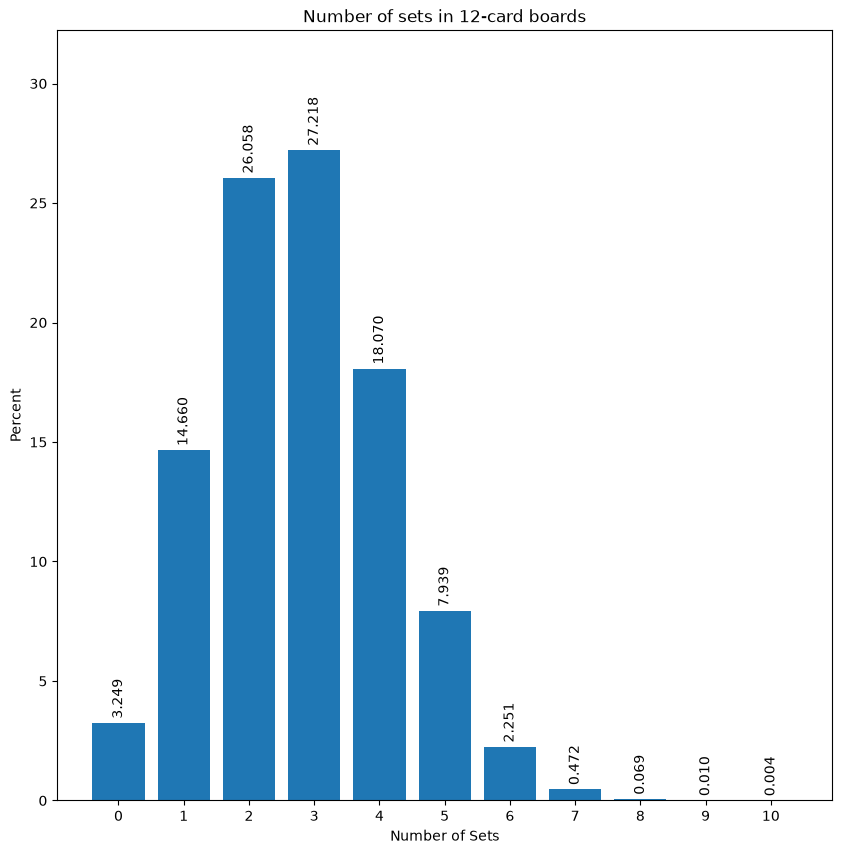

In [8]:
# sort by number of sets
items = sorted(outcomes.items())

labels = np.array([k for k, v in items], dtype=float)
sizes = np.array([v for k, v in items], dtype=float)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.bar(labels, sizes)

# labels on each bar
ax.bar_label(bars, labels=[f"{v:.3f}" for v in sizes], padding=3, rotation=90)
ax.set_ylim(0, max(sizes)+5)
ax.set_xticks(labels)
ax.set_title("Number of sets in 12-card boards")
ax.set_xlabel("Number of Sets")
ax.set_ylabel("Percent")

plt.show()

so of 12-card boards, there are about 3.2% of them will NOT have a single set. The peak is between 2-3 sets per 12-card board, 

Whaaat if I try it in C?

In [ ]:
byte_count = 707_243_201_847 * 12 * 4  #unique_boards * Cards per board * attributes per card
TB_count = byte_count/(1000**4)
print(f'Assuming a 4 byte int, the total search space would take {TB_count} TB')

Assuming a 4 byte int, the total search space would take 33.947673688656 TB


Okay this is kind of absurd. Is there a more performant way of checking for colinearity? 

a, b, and c, are arrays of 4 ints, e.g. [0, 1, 2, 0]

(all logic below is written in Python for readability)

#### 1. initial approach (pure python):
```
def check_colinearity(a, b, c):
    common_dims = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
    if 2 in lengths:
        return False, 0
    else:
        return True, common_dims.count(1)
```
I would like to keep the functionality of counting how many attributes are identical for all three sets, ideally.

#### 2. Current approach (C):
```
def c_colinearity(a, b, c):
    for i in range(4):
        if sum([a[i] + b[i] + c[i]]) % 3 == 0:
            continue
        else:
            return False
    return True
```
Elegant trick with checking for mod 3. 

#### 3. Hash approach: 
```
check_hashmap =  {frozenset({0}), frozenset({1}), frozenset({2}), frozenset({0, 1, 2})}

def hash_colinearity(a, b, c):
    for i in range(4):
        if frozenset((a[i], b[i], c[i])) in check_hashmap:
            continue
        else:
            return False
    return True
```
probably the fastest python way of doing it? This got me from a estimated 5.5 yrs to 2 years. 

#### 4. difference approach:

```
def c_colinearity(a, b, c):
    for i in range(4):
        sorted_vals = sorted(a[i], b[i], c[i]) #uses powersort? idk about sorting algos
        if sorted_vals[1] - sorted_vals[0] == sorted_vals[2] - sorted_vals[1]:
            continue
        else:
            return False
    return True
```
Would be flexible enough to account for values outside of (0, 1, 2), but that's not needed for this project. 

#### 5. array sum approach:

```
de arr_colinearity(a, b, c):
    common_attr = 0
    for i in range(4):
        idxs = [0, 0, 0]
        idxs[a[i]] = 1 ; idxs[b[i]] = 1 ; idxs[c[i]] = 1
        if sum(idxs) == 2:
            return False
        elif sum(idxs) == 1:
            common_attr += 1
    return True, common_attr
```

#### 6. Tree based approach:

Enumerate all sets into dicts for lookup
    There are 1080 sets, but we will need them in all iterative orders so 1080*6 = 6048 where you can index them as all_sets[a][b] == c
loop through, navigating through the tree and static lookup. 
This should be faster since you're dividing the amount of potential work by 4. 

In [12]:
!gcc -O3 tree_search_boards.c -o tree_search_boards

total_boards = combo_counter(81, 12)
print(f'Total Boards: {total_boards}')
trials = int(1e7)
board_size = 12

start_time = datetime.now()
!./tree_search_boards {trials} {board_size}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (24* 60 * 60)} days.')

Total Boards: 70724320184700
5: 2252200
6: 3215074
7: 1974960
8: 1314820
9: 845464
10: 317898
11: 12600
12: 46152
13: 18240
14: 2592
CLANG IMPLEMENTATION:
Tested 1.4139407736807528e-05% of the total space for board size 12, taking 2.295669 seconds.
At this rate, sampling the full space would take 187.9162377246413 days.


eliminating reflections/mirrors does NOT work here because 

1. Storing even a valid fraction takes way too much memory
2. With an in-place generator, you can't pre-eliminate possibilities, so you have to dynamically generate the canonical min for every combo at runtime.

# How many 15-card boards don't have sets?

oh boy. Let's see how long combo(81, 15) takes. 

In [ ]:
!gcc -O3 tree_search_boards.c -o tree_search_borads

total_boards = combo_counter(81, 15)
print(f'Total Boards: {total_boards}')
trials = int(1e7)
board_size = 15

start_time = datetime.now()
!./tree_search_boards {trials} {board_size}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (365.2425*24 * 60 * 60)} years.')

Total Boards: 8144022047817960
12: 914577
13: 1906669
14: 3240244
15: 2541168
16: 1115869
17: 182941
18: 79632
19: 13524
20: 1296
21: 3456
22: 576
23: 48
CLANG IMPLEMENTATION:
Tested 1.2278945146863048e-07% of the total space for board size 15, taking 3.747998 seconds.
At this rate, sampling the full space would take 96.72600302835845 years.


Oh no